# SHIVEN
## Major Project - Credit Risk Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_detection.csv')

In [3]:
print('Shape:', df.shape)
print('Columns', df.columns)
print(df.head())
print(df.info())
print(df.describe())
print("Null values", df.isnull().sum())
print("Duplicate:", df.duplicated().sum())
print('unique values:', df.nunique())

Shape: (41188, 60)
Columns Index(['age', 'campaign', 'pdays', 'previous', 'no_previous_contact',
       'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_w

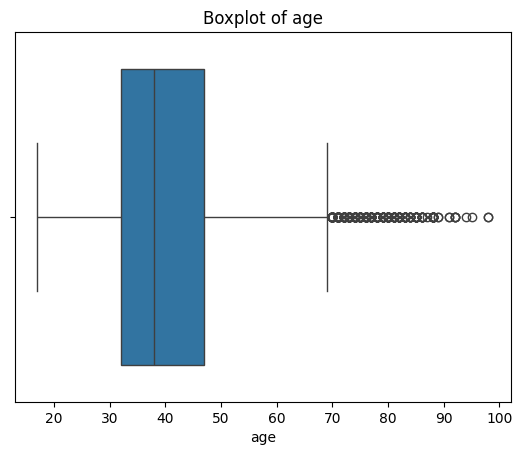

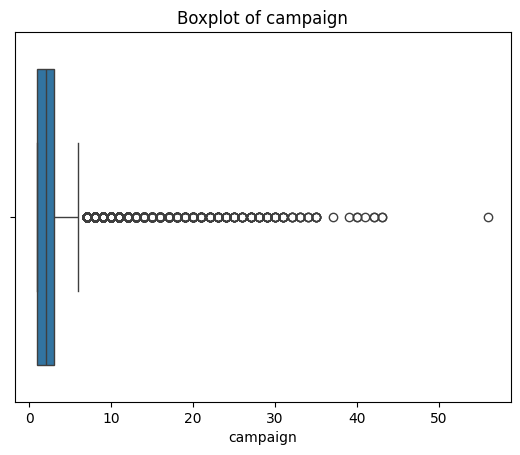

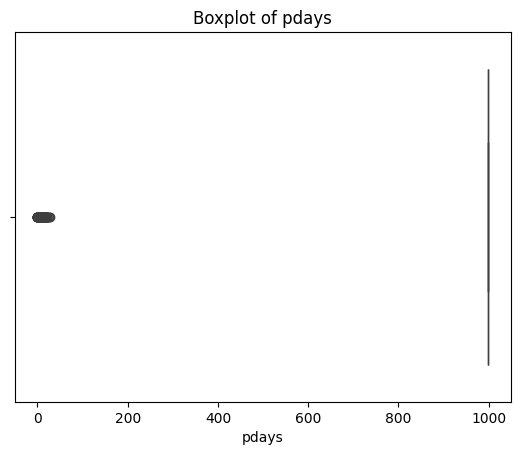

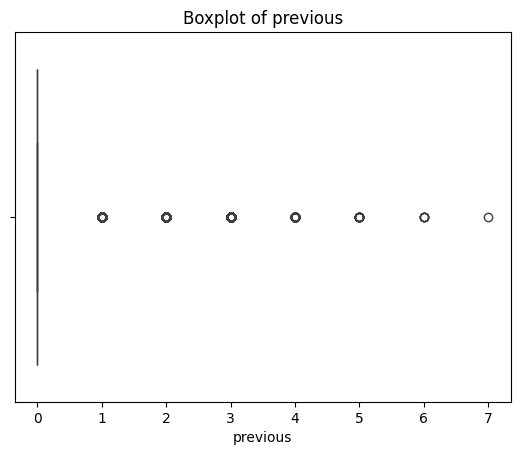

In [4]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous']

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [5]:
df.drop_duplicates(keep='first', inplace=True)

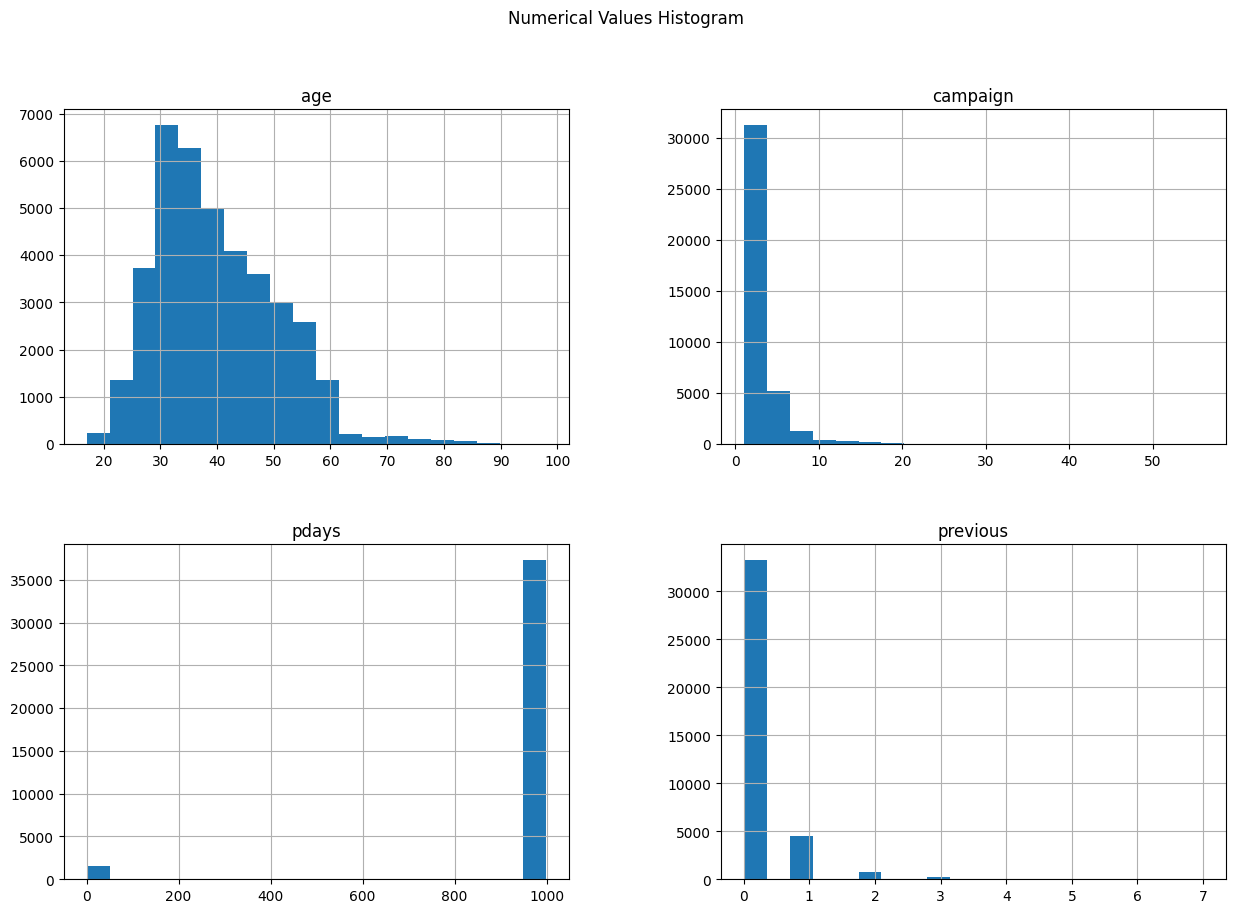

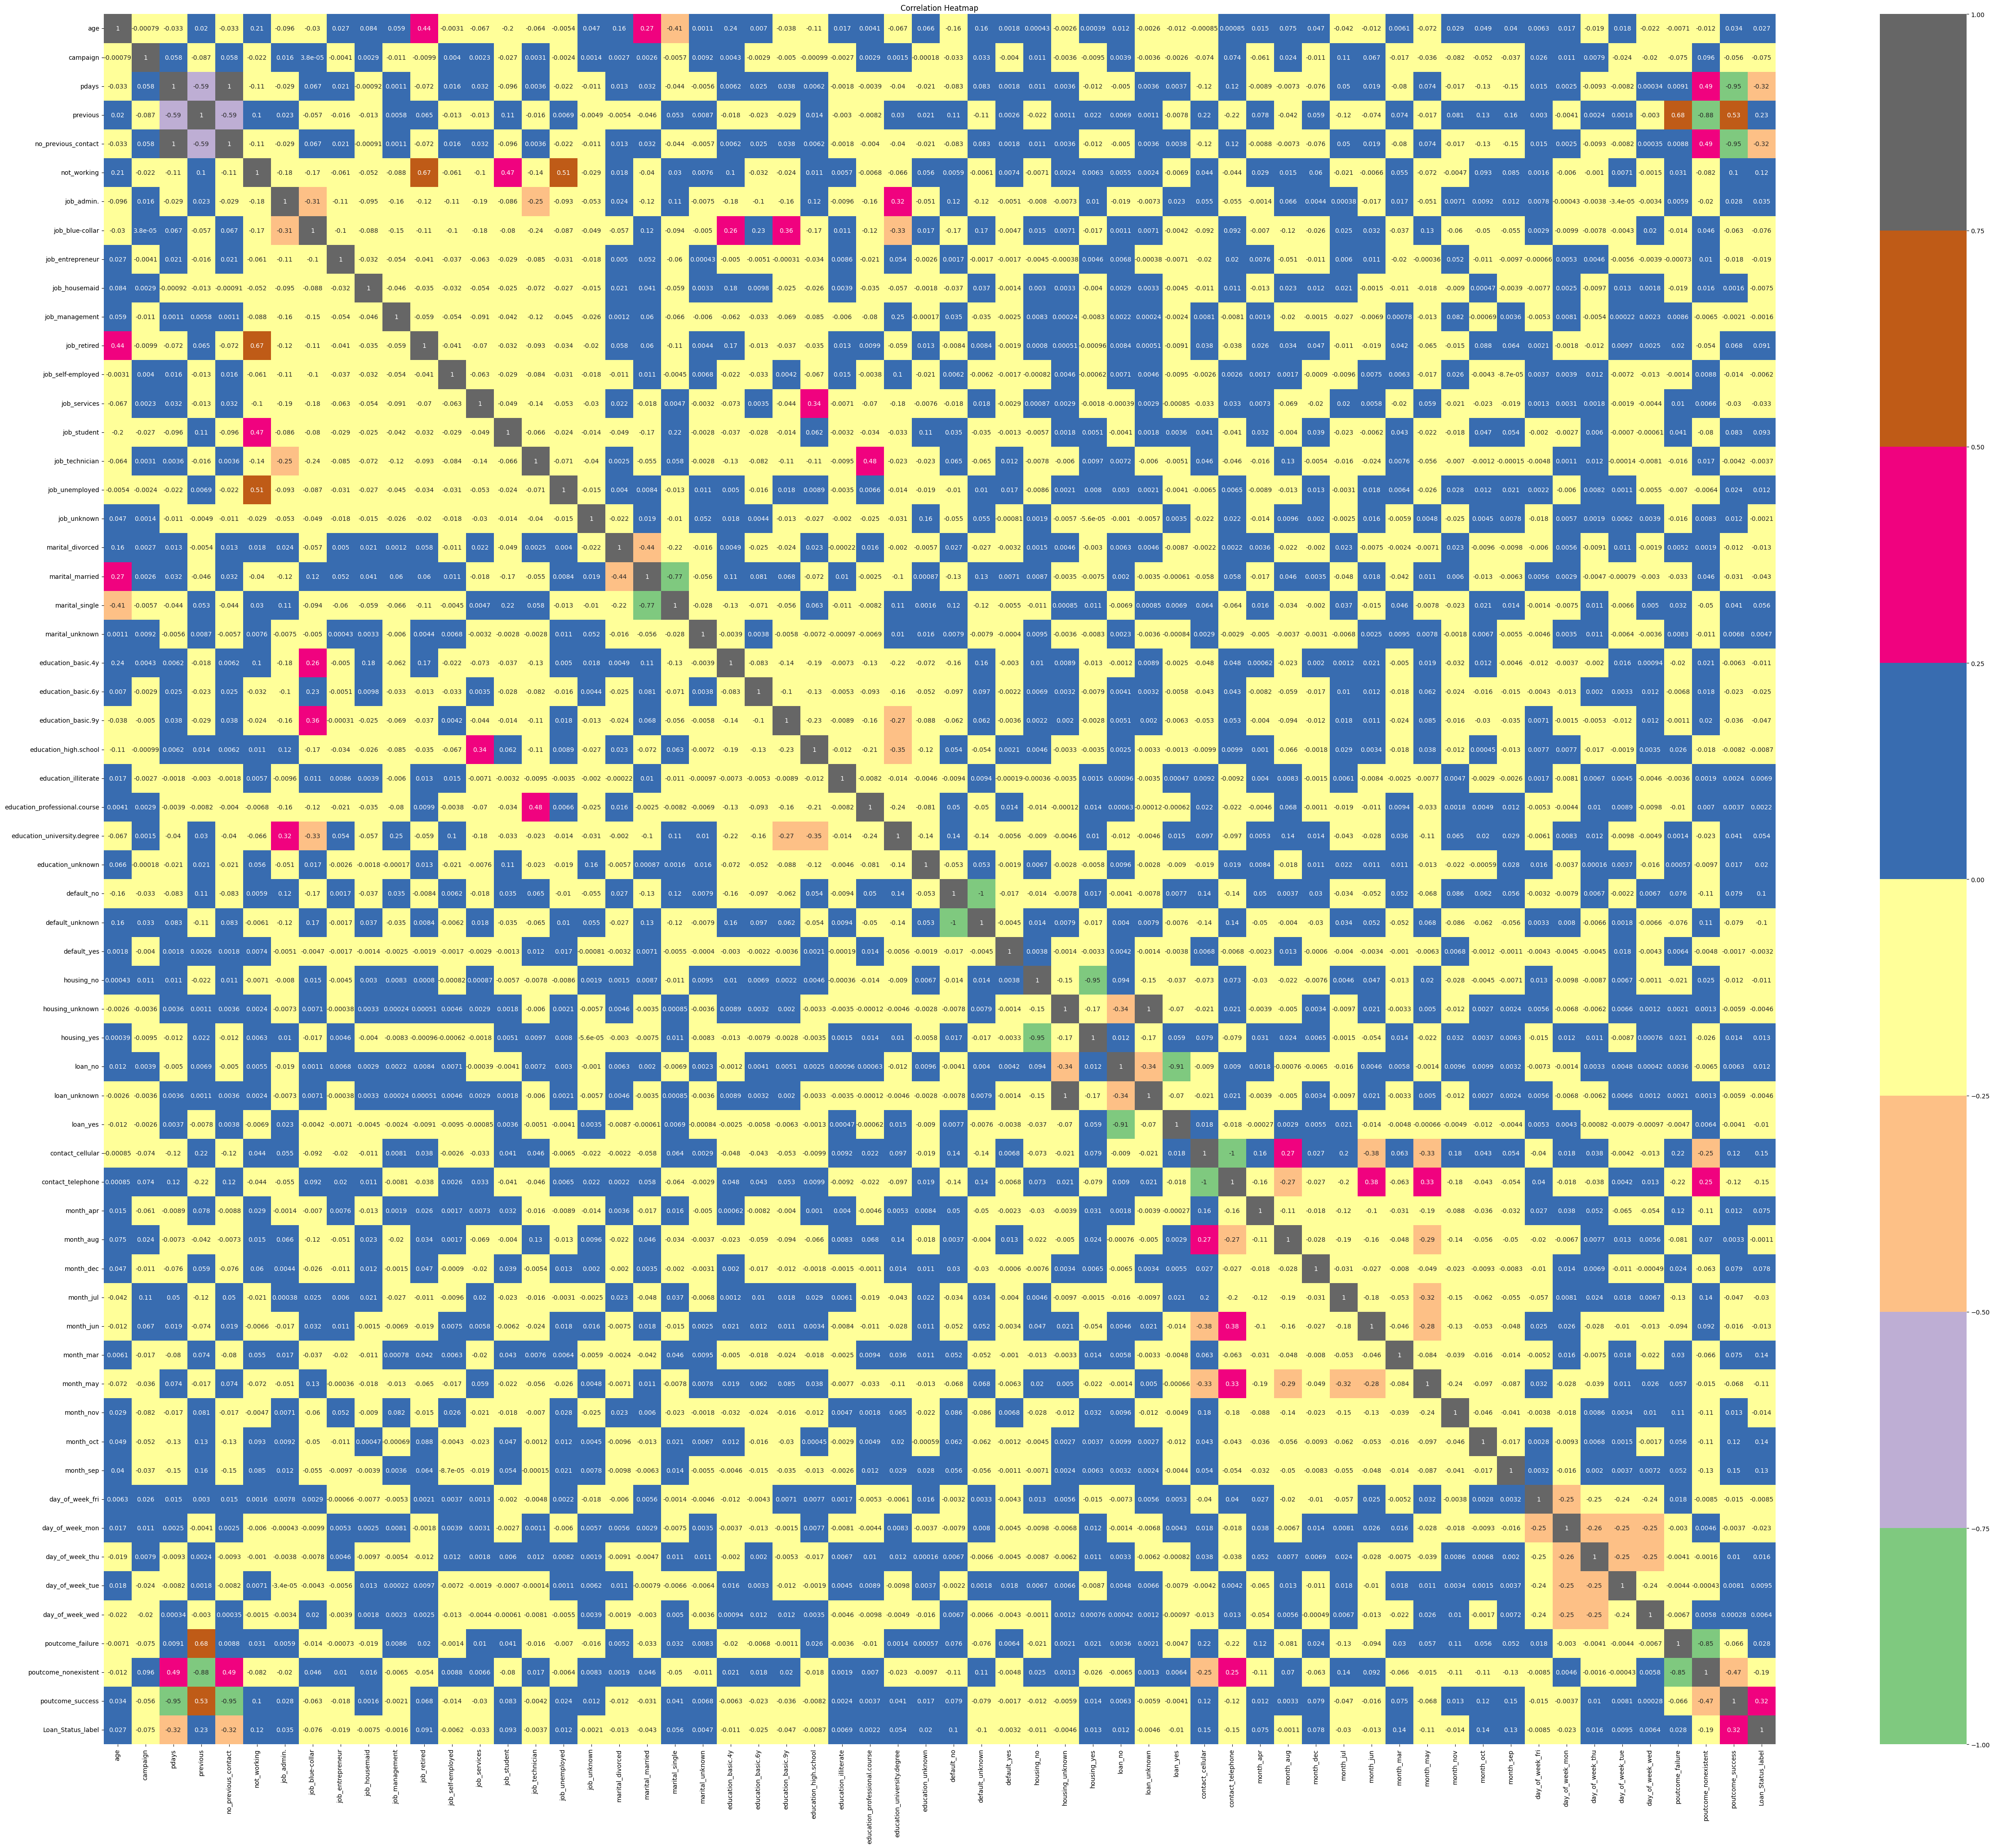

Correlation with target:
 pdays                           -0.324611
no_previous_contact             -0.324572
poutcome_nonexistent            -0.191993
contact_telephone               -0.152383
month_may                       -0.112099
default_unknown                 -0.103227
job_blue-collar                 -0.075625
campaign                        -0.074539
education_basic.9y              -0.047056
marital_married                 -0.043307
job_services                    -0.033042
month_jul                       -0.030064
education_basic.6y              -0.024966
day_of_week_mon                 -0.023220
job_entrepreneur                -0.019306
month_nov                       -0.014042
month_jun                       -0.013482
marital_divorced                -0.013390
housing_no                      -0.011295
education_basic.4y              -0.011243
loan_yes                        -0.010239
education_high.school           -0.008653
day_of_week_fri                 -0.008518
job_hous

In [6]:
df[numeric_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Numerical Values Histogram")
plt.show()

plt.figure(figsize=(60,50))
sns.heatmap(df.corr(), annot=True, cmap="Accent")
plt.title("Correlation Heatmap")
plt.savefig('heatmap.png')
plt.show()

corr_target = df.corr()['Loan_Status_label'].sort_values()
print("Correlation with target:\n", corr_target)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]


In [7]:
s_feat = corr_target[abs(corr_target) > 0.05].index.tolist()
s_feat = [col for col in s_feat if col != "Loan_Status_label"]

X_Full = df.drop('Loan_Status_label', axis=1)
X_Filtered = df[s_feat]

y = df["Loan_Status_label"]


X_train_full, X_test_full, y_train, y_test = train_test_split(X_Full, y, test_size=0.2, random_state=42, stratify=y)
X_train_filt, X_test_filt, _, _ = train_test_split(X_Filtered, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['age', 'campaign', 'pdays', 'previous']

num_cols_full = [col for col in num_cols if col in X_train_full.columns]
num_cols_filt = [col for col in num_cols if col in X_train_filt.columns]

scaler = StandardScaler()

X_train_full_scaled = X_train_full.copy()
X_train_full_scaled[num_cols_full] = scaler.fit_transform(X_train_full[num_cols_full])
X_test_full_scaled = X_test_full.copy()
X_test_full_scaled[num_cols_full] = scaler.transform(X_test_full[num_cols_full])

X_train_filt_scaled = X_train_filt.copy()
X_train_filt_scaled[num_cols_filt] = scaler.fit_transform(X_train_filt[num_cols_filt])
X_test_filt_scaled = X_test_filt.copy()
X_test_filt_scaled[num_cols_filt] = scaler.transform(X_test_filt[num_cols_filt])

In [8]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    
lr.fit(X_train_full, y_train)
y_pred_full = lr.predict(X_test_full)
print(f'Training Accuracy : {round(lr.score(X_train_full, y_train), 2)*100} %')
print(f'Test Accuracy : {round(lr.score(X_test_full, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

lr.fit(X_train_filt, y_train)
y_pred_filt = lr.predict(X_test_filt)
print(f"Training Accuracy : {round(lr.score(X_train_filt, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(lr.score(X_test_filt, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))


Training Accuracy : 67.0 %
Test Accuracy : 67.0 %
Confusion Matrix:
 [[3721 1842]
 [ 209  368]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.67      0.78      5563
           1       0.17      0.64      0.26       577

    accuracy                           0.67      6140
   macro avg       0.56      0.65      0.52      6140
weighted avg       0.87      0.67      0.74      6140

Training Accuracy : 61.0 %
Test Accuracy     : 60.0 %
Confusion Matrix:
 [[3293 2270]
 [ 173  404]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.59      0.73      5563
           1       0.15      0.70      0.25       577

    accuracy                           0.60      6140
   macro avg       0.55      0.65      0.49      6140
weighted avg       0.88      0.60      0.68      6140



In [9]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_full, y_train)
y_pred_full = dt.predict(X_test_full)
print(f'Training Accuracy : {round(dt.score(X_train_full, y_train), 2)*100} %')
print(f'Test Accuracy : {round(dt.score(X_test_full, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

dt.fit(X_train_filt, y_train)
y_pred_filt = dt.predict(X_test_filt)
print(f"Training Accuracy : {round(dt.score(X_train_filt, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(dt.score(X_test_filt, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))

dt_params = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_full, y_train)

dt_best = dt_grid.best_estimator_

print(f'Training Accuracy : {round(dt_best.score(X_train_full, y_train),2)*100} %')
print(f'Test Accuracy     : {round(dt_best.score(X_test_full, y_test),2)*100} %')

dt_grid_filt = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_filt.fit(X_train_filt, y_train)

dt_best_filt = dt_grid_filt.best_estimator_

print(f'Training Accuracy : {round(dt_best_filt.score(X_train_filt, y_train),2)*100} %')
print(f'Test Accuracy     : {round(dt_best_filt.score(X_test_filt, y_test),2)*100} %')


Training Accuracy : 99.0 %
Test Accuracy : 83.0 %
Confusion Matrix:
 [[4991  572]
 [ 459  118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5563
           1       0.17      0.20      0.19       577

    accuracy                           0.83      6140
   macro avg       0.54      0.55      0.55      6140
weighted avg       0.85      0.83      0.84      6140

Training Accuracy : 91.0 %
Test Accuracy     : 90.0 %
Confusion Matrix:
 [[5517   46]
 [ 541   36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      5563
           1       0.44      0.06      0.11       577

    accuracy                           0.90      6140
   macro avg       0.67      0.53      0.53      6140
weighted avg       0.87      0.90      0.87      6140

Training Accuracy : 91.0 %
Test Accuracy     : 91.0 %
Training Accuracy : 91.0 %
Test Accuracy     : 9

In [10]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_full, y_train)
y_pred_filt = rf.predict(X_test_full)
print(f"Training Accuracy : {round(rf.score(X_train_full, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(rf.score(X_test_full, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

rf.fit(X_train_filt, y_train)
y_pred_filt = rf.predict(X_test_filt)
print(f"Training Accuracy : {round(rf.score(X_train_filt, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(rf.score(X_test_filt, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))


'''#tuning params for better results
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_full, y_train)

# Best estimator                                              -----> all this took 16m to run on google colab so i commented this

rf_best = rf_grid.best_estimator_

# Evaluate
print(f'Training Accuracy : {round(rf_best.score(X_train_full, y_train),2)*100} %')       #Training Accuracy : 91.0 %

print(f'Test Accuracy     : {round(rf_best.score(X_test_full, y_test),2)*100} %')         #Test Accuracy     : 91.0 %


# GridSearchCV for filtered dataset
rf_grid_filt = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid_filt.fit(X_train_filt, y_train)

# Best estimator
rf_best_filt = rf_grid_filt.best_estimator_

# Evaluate
print(f'Training Accuracy : {round(rf_best_filt.score(X_train_filt, y_train),2)*100} %')    #Training Accuracy : 91.0 %

print(f'Test Accuracy     : {round(rf_best_filt.score(X_test_filt, y_test),2)*100} %')       #Test Accuracy     : 91.0 %'''


Training Accuracy : 99.0 %
Test Accuracy     : 89.0 %
Confusion Matrix:
 [[4991  572]
 [ 459  118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5563
           1       0.17      0.20      0.19       577

    accuracy                           0.83      6140
   macro avg       0.54      0.55      0.55      6140
weighted avg       0.85      0.83      0.84      6140

Training Accuracy : 91.0 %
Test Accuracy     : 90.0 %
Confusion Matrix:
 [[5508   55]
 [ 532   45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      5563
           1       0.45      0.08      0.13       577

    accuracy                           0.90      6140
   macro avg       0.68      0.53      0.54      6140
weighted avg       0.87      0.90      0.87      6140



"#tuning params for better results\nrf_params = {\n    'n_estimators': [100, 200, 300],\n    'max_depth': [None, 10, 20, 30],\n    'min_samples_split': [2, 5, 10],\n    'min_samples_leaf': [1, 2, 4],\n    'criterion': ['gini', 'entropy']\n}\n\n# GridSearchCV\nrf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)\nrf_grid.fit(X_train_full, y_train)\n\n# Best estimator                                              -----> all this took 16m to run on google colab so i commented this\n\nrf_best = rf_grid.best_estimator_\n\n# Evaluate\nprint(f'Training Accuracy : {round(rf_best.score(X_train_full, y_train),2)*100} %')       #Training Accuracy : 91.0 %\n\nprint(f'Test Accuracy     : {round(rf_best.score(X_test_full, y_test),2)*100} %')         #Test Accuracy     : 91.0 %\n\n\n# GridSearchCV for filtered dataset\nrf_grid_filt = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)\nrf_grid_filt.fit(X_train_filt, y_train)\n\n# Best estimator\nrf_best_filt = rf_gri

In [11]:
adb = AdaBoostClassifier(n_estimators=100, random_state=42)

adb.fit(X_train_full, y_train)
y_pred_filt = adb.predict(X_test_full)
print(f'Training Accuracy : {round(adb.score(X_train_full, y_train), 2)*100} %')
print(f'Test Accuracy     : {round(adb.score(X_test_full, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

adb.fit(X_train_filt, y_train)
y_pred_filt = adb.predict(X_test_filt)
print(f'Training Accuracy : {round(adb.score(X_train_filt, y_train), 2)*100} %')
print(f'Test Accuracy     : {round(adb.score(X_test_filt, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))

Training Accuracy : 91.0 %
Test Accuracy     : 91.0 %
Confusion Matrix:
 [[4991  572]
 [ 459  118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5563
           1       0.17      0.20      0.19       577

    accuracy                           0.83      6140
   macro avg       0.54      0.55      0.55      6140
weighted avg       0.85      0.83      0.84      6140

Training Accuracy : 91.0 %
Test Accuracy     : 91.0 %
Confusion Matrix:
 [[5563    0]
 [ 577    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      5563
           1       0.00      0.00      0.00       577

    accuracy                           0.91      6140
   macro avg       0.45      0.50      0.48      6140
weighted avg       0.82      0.91      0.86      6140



In [12]:
svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train_full, y_train)
y_pred_filt = svm.predict(X_test_full)
print(f'Training Accuracy : {round(svm.score(X_train_full, y_train), 2)*100} %')
print(f'Test Accuracy : {round(svm.score(X_test_full, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

svm.fit(X_train_filt, y_train)
y_pred_filt = svm.predict(X_test_filt)
print(f"Training Accuracy : {round(svm.score(X_train_filt, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(svm.score(X_test_filt, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))

Training Accuracy : 91.0 %
Test Accuracy : 91.0 %
Confusion Matrix:
 [[4991  572]
 [ 459  118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5563
           1       0.17      0.20      0.19       577

    accuracy                           0.83      6140
   macro avg       0.54      0.55      0.55      6140
weighted avg       0.85      0.83      0.84      6140

Training Accuracy : 91.0 %
Test Accuracy     : 91.0 %
Confusion Matrix:
 [[5563    0]
 [ 577    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      5563
           1       0.00      0.00      0.00       577

    accuracy                           0.91      6140
   macro avg       0.45      0.50      0.48      6140
weighted avg       0.82      0.91      0.86      6140



In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_full, y_train)
y_pred_filt = knn.predict(X_test_full)
print(f'Training Accuracy : {round(knn.score(X_train_full, y_train), 2)*100} %')
print(f'Test Accuracy : {round(knn.score(X_test_full, y_test), 2)*100} %')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
print("Classification Report:\n", classification_report(y_test, y_pred_full))

knn.fit(X_train_filt, y_train)
y_pred_filt = knn.predict(X_test_filt)
print(f"Training Accuracy : {round(knn.score(X_train_filt, y_train), 2) * 100} %")
print(f"Test Accuracy     : {round(knn.score(X_test_filt, y_test), 2) * 100} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
print("Classification Report:\n", classification_report(y_test, y_pred_filt))

Training Accuracy : 91.0 %
Test Accuracy : 90.0 %
Confusion Matrix:
 [[4991  572]
 [ 459  118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5563
           1       0.17      0.20      0.19       577

    accuracy                           0.83      6140
   macro avg       0.54      0.55      0.55      6140
weighted avg       0.85      0.83      0.84      6140

Training Accuracy : 90.0 %
Test Accuracy     : 90.0 %
Confusion Matrix:
 [[5459  104]
 [ 525   52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95      5563
           1       0.33      0.09      0.14       577

    accuracy                           0.90      6140
   macro avg       0.62      0.54      0.54      6140
weighted avg       0.86      0.90      0.87      6140



In [14]:
smote = SMOTE(random_state=42)

X_train_full_sm, y_train_full_sm = smote.fit_resample(X_train_full, y_train)

X_train_filt_sm, y_train_filt_sm = smote.fit_resample(X_train_filt, y_train)

In [15]:
scaler = StandardScaler()

X_train_full_sm_scaled = scaler.fit_transform(X_train_full_sm)
X_test_full_scaled = scaler.transform(X_test_full)

X_train_filt_sm_scaled = scaler.fit_transform(X_train_filt_sm)
X_test_filt_scaled = scaler.transform(X_test_filt)

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

for name, model in models.items():
    print(f"\n{name} - Full Features")
    model.fit(X_train_full_sm_scaled, y_train_full_sm)
    y_pred_full = model.predict(X_test_full_scaled)
    print(f"Training Accuracy : {round(model.score(X_train_full_sm_scaled, y_train_full_sm), 2) * 100} %")
    print(f"Test Accuracy     : {round(model.score(X_test_full_scaled, y_test), 2) * 100} %")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_full))
    print("Classification Report:\n", classification_report(y_test, y_pred_full))
    
    print(f"{name} - Filtered Features")
    model.fit(X_train_filt_sm_scaled, y_train_filt_sm)
    y_pred_filt = model.predict(X_test_filt_scaled)
    print(f"Training Accuracy : {round(model.score(X_train_filt_sm_scaled, y_train_filt_sm), 2) * 100} %")
    print(f"Test Accuracy     : {round(model.score(X_test_filt_scaled, y_test), 2) * 100} %")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_filt))
    print("Classification Report:\n", classification_report(y_test, y_pred_filt))


Logistic Regression - Full Features
Training Accuracy : 94.0 %
Test Accuracy     : 91.0 %
Confusion Matrix:
 [[5525   38]
 [ 536   41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      5563
           1       0.52      0.07      0.12       577

    accuracy                           0.91      6140
   macro avg       0.72      0.53      0.54      6140
weighted avg       0.87      0.91      0.87      6140

Logistic Regression - Filtered Features
Training Accuracy : 64.0 %
Test Accuracy     : 60.0 %
Confusion Matrix:
 [[3264 2299]
 [ 173  404]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.59      0.73      5563
           1       0.15      0.70      0.25       577

    accuracy                           0.60      6140
   macro avg       0.55      0.64      0.49      6140
weighted avg       0.87      0.60      0.68      6140


Decision Tree - Full